<a href="https://colab.research.google.com/github/sabovicveljko/Monte-Carlo-Portfolio-Optimisation/blob/main/MCPO_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Environment Setup

In [84]:
#!pip install yfinance --upgrade

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:.4f}'.format)
%matplotlib inline
print("Success: Libraries imported and environment is ready.")

Success: Libraries imported and environment is ready.


# Step 2: Data Acquisition
In this step, we define our portfolio assets and download 10 years of historical data.

In [4]:
tickers = ['AAPL', 'NVDA', 'AMD', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'NIO', 'JPM', 'BAC', 'V', 'KO', 'PEP', 'XOM', 'JNJ', 'PFE', 'WMT', 'PG', 'NKE', 'GLD']
start_date = '2016-05-01'
end_date = '2026-05-01'
raw_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)
data = raw_data['Close']

print("\nSuccess: Historical data downloaded.")
data.head()

[*********************100%***********************]  20 of 20 completed


Success: Historical data downloaded.


Ticker,AAPL,AMD,AMZN,BAC,GLD,GOOGL,JNJ,JPM,KO,MSFT,NIO,NKE,NVDA,PEP,PFE,PG,TSLA,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,
2016-05-02,21.188107,3.74,34.192501,11.841370,123.239998,35.427692,85.639641,48.889771,32.878975,44.531181,NaN,52.238075,0.881284,76.378174,19.759783,61.641224,16.120001,72.992989,18.842264,57.653770
2016-05-03,21.536568,3.60,33.566002,11.512668,122.959999,35.131641,85.594086,47.947071,32.776646,43.800873,NaN,52.176731,0.870758,76.474182,20.301971,61.740196,15.488000,71.811470,18.677778,56.994003
2016-05-04,21.312559,3.60,33.544998,11.328271,122.209999,35.276939,85.237091,47.188313,32.878975,43.880066,NaN,51.817310,0.850929,76.813858,20.121248,62.120846,14.837333,71.699829,18.730757,56.884029
2016-05-05,21.226055,3.66,32.954498,11.264132,122.070000,35.442566,85.738403,46.935394,32.937462,43.941666,NaN,51.010807,0.856070,76.954178,20.223656,61.892456,14.102000,71.969635,18.736332,56.948719
2016-05-06,21.107677,3.68,33.697498,11.312238,123.180000,35.961777,85.632057,47.211315,33.127522,44.337608,NaN,51.221214,0.864883,77.508011,20.229679,62.524311,14.328667,72.304550,19.026251,57.252758


# Step 3: Data Cleaning and Preprocessing
Handling missing values and ensuring data integrity.

In [5]:
print("Missing values count per asset:")
print(data.isnull().sum())

data = data.ffill().dropna()
print(f"\nSuccess: Data cleaned. Final dataset shape: {data.shape}")

Missing values count per asset:
Ticker
AAPL       0
AMD        0
AMZN       0
BAC        0
GLD        0
GOOGL      0
JNJ        0
JPM        0
KO         0
MSFT       0
NIO      596
NKE        0
NVDA       0
PEP        0
PFE        0
PG         0
TSLA       0
V          0
WMT        0
XOM        0
dtype: int64

Success: Data cleaned. Final dataset shape: (1918, 20)


# Step 4: Financial Metrics Calculation
Calculating daily returns, annualized mean returns, and the covariance matrix.

In [6]:
daily_returns = data.pct_change().dropna()
annual_mean_returns = daily_returns.mean() * 252
cov_matrix = daily_returns.cov() * 252

print("Success: Returns and Covariance matrix calculated.")
print("\nAnnualized Mean Returns:")
print(annual_mean_returns)

Success: Returns and Covariance matrix calculated.

Annualized Mean Returns:
Ticker
AAPL     0.264934
AMD      0.470471
AMZN     0.189797
BAC      0.150708
GLD      0.187054
GOOGL    0.298051
JNJ      0.112115
JPM      0.205263
KO       0.120812
MSFT     0.221738
NIO      0.350740
NKE     -0.008765
NVDA     0.582105
PEP      0.096032
PFE      0.024953
PG       0.122100
TSLA     0.593976
V        0.148190
WMT      0.225529
XOM      0.173908
dtype: float64


# Step 5: Portfolio Performance Logic
Defining a function to calculate the return and volatility for a given set of weights.

In [7]:
def portfolio_performance(weights, annual_mean_returns, cov_matrix):
    returns = np.sum(annual_mean_returns * weights)
    std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return returns, std_dev

print("Success: Performance function is ready for Monte Carlo simulation.")

Success: Performance function is ready for Monte Carlo simulation.


# Step 6: Monte Carlo Simulation -- P1
In this step, we make a function that simulates n random portfolio weight allocations
and computes the expected return, volatility, and Sharpe ratio for each.

In [76]:
np.random.seed(2026) # Rerun this cell before every simulation to get the same independent results

In [75]:
# Monte Carlo parameters
num_portfolios1 = 1000
num_portfolios2 = 50000
num_portfolios_final= 100000
risk_free_rate = 0.045 # around the average for us treasury bonds in the last 10 years

# Monte Carlo simulation
def monte_carlo_simulation(num_portfolios, annual_mean_returns, cov_matrix, risk_free_rate):

    loc_num_assets = len(annual_mean_returns)

    # Storage arrays
    mc_returns = np.zeros(num_portfolios)
    mc_volatility = np.zeros(num_portfolios)
    mc_sharpe = np.zeros(num_portfolios)

    # Store portfolio weights
    mc_weights = np.zeros((num_portfolios, loc_num_assets))

    for i in range(num_portfolios):

        # Generate random weights
        weights = np.random.random(loc_num_assets)

        # Normalize weights so they sum to 1
        weights /= np.sum(weights)

        # Store weights
        mc_weights[i] = weights

        # Portfolio performance
        portfolio_return, portfolio_std_dev = portfolio_performance(
            weights,
            annual_mean_returns,
            cov_matrix
        )

        # Store results
        mc_returns[i] = portfolio_return
        mc_volatility[i] = portfolio_std_dev

        # Sharpe ratio
        mc_sharpe[i] = (
            portfolio_return - risk_free_rate
        ) / portfolio_std_dev

    return mc_returns, mc_volatility, mc_sharpe, mc_weights

In [62]:
mc_returns1, mc_volatility1, mc_sharpe1, mc_weights1 = monte_carlo_simulation(
    num_portfolios1,
    annual_mean_returns,
    cov_matrix,
    risk_free_rate
)

In [56]:
mc_returns2, mc_volatility2, mc_sharpe2, mc_weights2 = monte_carlo_simulation(
    num_portfolios2,
    annual_mean_returns,
    cov_matrix,
    risk_free_rate
)

In [72]:
mc_returns, mc_volatility, mc_sharpe, mc_weights = monte_carlo_simulation(
    num_portfolios_final,
    annual_mean_returns,
    cov_matrix,
    risk_free_rate
)

In [12]:
def get_best(mc_returns, mc_volatility, mc_sharpe, mc_weights):

    max_sharpe_idx = np.argmax(mc_sharpe)
    min_var_idx = np.argmin(mc_volatility)

    return {
        "max_sharpe_return": mc_returns[max_sharpe_idx],
        "max_sharpe_vol": mc_volatility[max_sharpe_idx],
        "max_sharpe_ratio": mc_sharpe[max_sharpe_idx],
        "max_sharpe_weights": mc_weights[max_sharpe_idx],

        "min_var_return": mc_returns[min_var_idx],
        "min_var_vol": mc_volatility[min_var_idx],
        "min_var_weights": mc_weights[min_var_idx]
    }

In [73]:
res1 = get_best(mc_returns1, mc_volatility1, mc_sharpe1, mc_weights1)
res2 = get_best(mc_returns2, mc_volatility2, mc_sharpe2, mc_weights2)
res3 = get_best(mc_returns, mc_volatility, mc_sharpe, mc_weights)

In [74]:
comparison = pd.DataFrame([
    {
        "Simulations": "1k",
        "Max Sharpe": res1["max_sharpe_ratio"],
        "Return": res1["max_sharpe_return"],
        "Volatility": res1["max_sharpe_vol"]
    },
    {
        "Simulations": "50k",
        "Max Sharpe": res2["max_sharpe_ratio"],
        "Return": res2["max_sharpe_return"],
        "Volatility": res2["max_sharpe_vol"]
    },
    {
        "Simulations": "100k",
        "Max Sharpe": res3["max_sharpe_ratio"],
        "Return": res3["max_sharpe_return"],
        "Volatility": res3["max_sharpe_vol"]
    }
])

print(comparison)

  Simulations  Max Sharpe    Return  Volatility
0          1k    1.075269  0.288633    0.226578
1         50k    1.117587  0.279653    0.209964
2        100k    1.117587  0.279653    0.209964


In [18]:
mc_df = pd.DataFrame({
    'Return': mc_returns,
    'Volatility': mc_volatility,
    'Sharpe': mc_sharpe
})

Let's see how should we invest 10 000 EUR if we were to listen to this simulation.

In [77]:
investment = 10000

In [78]:
max_idx = np.argmax(mc_sharpe)

mc_best_weights = mc_weights[max_idx]

In [82]:
portfolio_allocation_by_mc = pd.DataFrame({
    "Stock": tickers,
    "Weight": mc_best_weights,
    "Amount (€)": mc_best_weights * investment
})

print(portfolio_allocation_by_mc.sort_values("Weight", ascending=False))

    Stock    Weight   Amount (€)
4   GOOGL  0.151825  1518.250779
16    WMT  0.134574  1345.744791
6    TSLA  0.105380  1053.800761
0    AAPL  0.091215   912.153157
5    AMZN  0.085356   853.557976
12    PEP  0.061094   610.940490
1    NVDA  0.050760   507.604631
19    GLD  0.049038   490.380160
3    MSFT  0.047521   475.207963
13    XOM  0.043345   433.452653
18    NKE  0.036754   367.541861
14    JNJ  0.033213   332.126159
17     PG  0.025949   259.492272
9     BAC  0.019910   199.101386
7     NIO  0.018811   188.108125
8     JPM  0.017067   170.673245
10      V  0.013630   136.298593
2     AMD  0.011044   110.441288
15    PFE  0.003473    34.734951
11     KO  0.000039     0.388759


Let's see how the safest mc portfolio performed and how safe is it.

In [87]:
min_vol_idx = np.argmin(mc_volatility)

In [91]:
min_vol_weights = mc_weights[min_vol_idx]
min_vol_return = mc_returns[min_vol_idx]
min_vol = mc_volatility[min_vol_idx]
min_vol_sharpe = mc_sharpe[min_vol_idx]

In [92]:
print(f"Min Volatility → Return: {min_vol_return:.2%}, Volatility: {min_vol:.2%}, Sharpe: {min_vol_sharpe:.4f}")

Min Volatility → Return: 16.10%, Volatility: 15.31%, Sharpe: 0.7576


# Step 7: Gradient-Based Optimisation -- P2
Using scipy.optimize.minimize (SLSQP) to find the exact
minimum-variance and maximum-Sharpe portfolios, and comparing
them against the Monte Carlo simulation envelope.

In [19]:
#!pip install scipy
from scipy.optimize import minimize
num_assets = len(annual_mean_returns)

constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for _ in range(num_assets))
init_weights = np.ones(num_assets) / num_assets

# Minimum Variance
def min_variance(weights):
    return portfolio_performance(weights, annual_mean_returns, cov_matrix)[1]

result_minvar = minimize(min_variance, init_weights,
                         method='SLSQP', bounds=bounds, constraints=constraints)
minvar_ret, minvar_vol = portfolio_performance(result_minvar.x, annual_mean_returns, cov_matrix)
minvar_sharpe = (minvar_ret - risk_free_rate) / minvar_vol

# Maximum Sharpe
def neg_sharpe(weights):
    ret, vol = portfolio_performance(weights, annual_mean_returns, cov_matrix)
    return -(ret - risk_free_rate) / vol

result_maxsharpe = minimize(neg_sharpe, init_weights,
                            method='SLSQP', bounds=bounds, constraints=constraints)
maxsh_ret, maxsh_vol = portfolio_performance(result_maxsharpe.x, annual_mean_returns, cov_matrix)
maxsh_sharpe = (maxsh_ret - risk_free_rate) / maxsh_vol

print(f"Min Variance → Return: {minvar_ret:.2%}, Volatility: {minvar_vol:.2%}, Sharpe: {minvar_sharpe:.4f}")
print(f"Max Sharpe   → Return: {maxsh_ret:.2%},  Volatility: {maxsh_vol:.2%}, Sharpe: {maxsh_sharpe:.4f}")

Min Variance → Return: 16.16%, Volatility: 11.90%, Sharpe: 0.9800
Max Sharpe   → Return: 28.37%,  Volatility: 16.45%, Sharpe: 1.4508


Let's see how should we invest 10 000 EUR if we were to listen to the optimization.

In [85]:
opt_weights = result_maxsharpe.x
opt_weights[np.abs(opt_weights) < 1e-4] = 0


In [86]:
portfolio_allocation_by_opt = pd.DataFrame({
    "Stock": tickers,
    "Weight": opt_weights,
    "Amount (€)": opt_weights * investment
})

print(portfolio_allocation_by_opt.sort_values("Weight", ascending=False))

    Stock  Weight  Amount (€)
4   GOOGL  0.4713   4712.6319
18    NKE  0.2603   2602.5257
12    PEP  0.1390   1389.7726
16    WMT  0.0729    728.8301
19    GLD  0.0283    283.4729
5    AMZN  0.0205    205.0960
7     NIO  0.0078     77.6708
0    AAPL  0.0000      0.0000
3    MSFT  0.0000      0.0000
2     AMD  0.0000      0.0000
1    NVDA  0.0000      0.0000
6    TSLA  0.0000      0.0000
11     KO  0.0000      0.0000
10      V  0.0000      0.0000
9     BAC  0.0000      0.0000
8     JPM  0.0000      0.0000
15    PFE  0.0000      0.0000
14    JNJ  0.0000      0.0000
13    XOM  0.0000      0.0000
17     PG  0.0000      0.0000


# Step 8: Efficient Frontier Visualisation -- P3
Plotting all 100,000 simulated portfolios, marking the optimal
portfolios found by scipy, and drawing the Capital Market Line
using the risk-free rate.

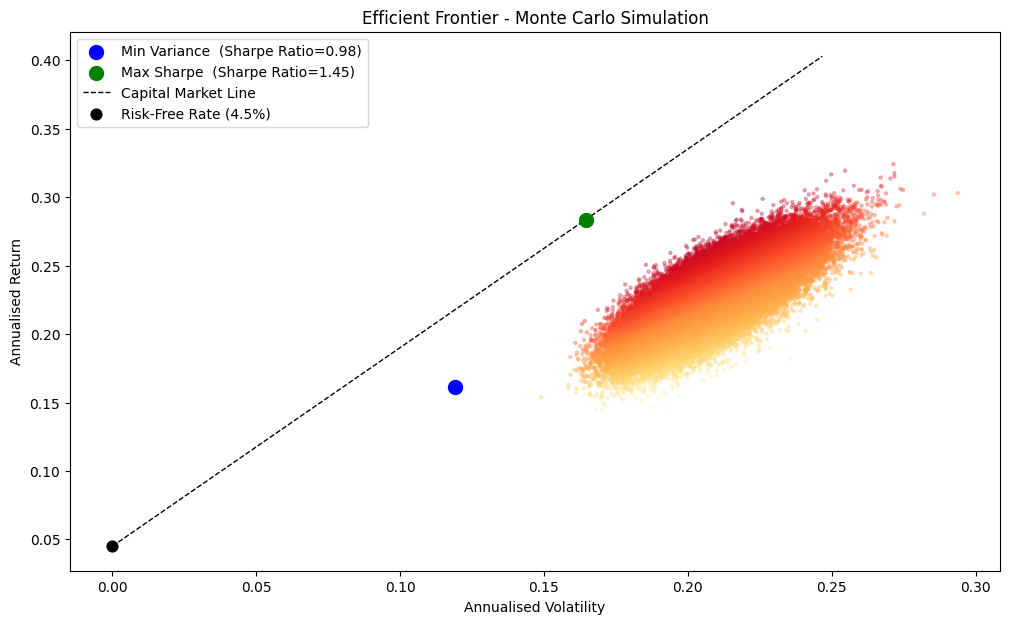

In [90]:
plt.figure(figsize=(12, 7))

# Monte Carlo cloud (The 50.000 portfolio's annualised performance // Each dot represents a portfolio)
plt.scatter(mc_df['Volatility'], mc_df['Return'],
            c=mc_df['Sharpe'], cmap='YlOrRd',
            alpha=0.3, s=5)

# Min Variance portfolio (Lowest risk portfolio // Ignores return on risk)
plt.scatter(minvar_vol, minvar_ret, marker='o', color='blue',
            s=100, zorder=5, label=f'Min Variance  (Sharpe Ratio={minvar_sharpe:.2f})')

# Max Sharpe portfolio (Best risk to return ratio portfolio)
plt.scatter(maxsh_vol, maxsh_ret, marker='o', color='green',
            s=100, zorder=5, label=f'Max Sharpe  (Sharpe Ratio={maxsh_sharpe:.2f})')

# Capital Market Line (Connects Risk free point to Max sharpe point)
cml_x = np.linspace(0, maxsh_vol * 1.5, 100)
cml_y = risk_free_rate + maxsh_sharpe * cml_x
plt.plot(cml_x, cml_y, 'k--', linewidth=1, label='Capital Market Line')

# Risk-free rate point (US bonds rate // 0 risk - low return investment)
plt.scatter(0, risk_free_rate, marker='o', color='black',
            s=60, zorder=5, label=f'Risk-Free Rate ({risk_free_rate:.1%})')

plt.xlabel('Annualised Volatility')
plt.ylabel('Annualised Return')
plt.title('Efficient Frontier - Monte Carlo Simulation')
plt.legend()
plt.show()

# Step 9: Impact of the Risk-Free Asset

## Observations

When a risk-free asset is added to the portfolio universe, the efficient
frontier fundamentally changes. Instead of being constrained to the curved
parabolic frontier, investors can now combine any amount of the **tangency
portfolio** (Maximum Sharpe portfolio) with the risk-free asset.

This combination traces a straight line called the **Capital Market Line (CML)**:

- The CML starts at the risk-free rate (σ=0, r=5%) on the y-axis
- It passes through the tangency (Maximum Sharpe) portfolio
- Every point on the CML **dominates** the curved frontier below it —
  same return for less risk, or more return for the same risk

## Key Takeaway

Without a risk-free asset → investors are limited to the curved frontier.  
With a risk-free asset → investors can reach any point on the CML by mixing
the tangency portfolio with cash, achieving a **better risk-return tradeoff**
than any purely risky portfolio below the line.

## scipy vs Monte Carlo Comparison

The scipy optimizer found portfolios nearly identical to the best portfolios
in the Monte Carlo cloud, confirming that 50,000 simulations were sufficient
to approximate the true frontier. The gradient-based optimizer is more precise
but Monte Carlo gives a richer picture of the full opportunity set.